# 0. Environment Setup and Installations

In [ ]:
# 1. Mount Google Drive to access your files
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


# 2. Unzip the dataset to local Colab storage for fast access
#print("Unzipping dataset... this might take a few minutes.")
#!unzip -q "/content/drive/MyDrive/Celeb-DF-v2.zip" -d "/content/dataset"
#print("Unzip complete!")

# 3. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow mtcnn tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.1 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


# 0.5 Copy Img from Drive

In [ ]:
import os
import shutil
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

src_dir = '/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2'
dest_dir = '/content/Balanced_Dataset_V2'

print("Scanning files in Drive (this takes a minute)...")
files_to_copy = []

# סריקת הדרייב ובניית מבנה התיקיות ביעד
for root, dirs, files in os.walk(src_dir):
    dest_path = root.replace(src_dir, dest_dir)
    os.makedirs(dest_path, exist_ok=True)
    for file in files:
        files_to_copy.append(os.path.join(root, file))

print(f"Found {len(files_to_copy)} files. Starting parallel copy...")

# פונקציית העתקה (מדלגת על קבצים שכבר עברו למקרה של הפסקה)
def copy_file(file_path):
    dest_path = file_path.replace(src_dir, dest_dir)
    if not os.path.exists(dest_path):
        shutil.copy2(file_path, dest_path)

# העתקה מקבילית (הרבה יותר מהירה מ-cp) עם סרגל התקדמות
with ThreadPoolExecutor(max_workers=16) as executor:
    list(tqdm(executor.map(copy_file, files_to_copy), total=len(files_to_copy)))

print("Copy completed successfully!")

Scanning files in Drive (this takes a minute)...
Found 19904 files. Starting parallel copy...


  0%|          | 0/19904 [00:00<?, ?it/s]

Copy completed successfully!


#1. Data Pipeline: Face Extraction to Drive

In [ ]:
import os
import cv2
import random
import numpy as np
from mtcnn import MTCNN
from PIL import Image
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive to save the extracted dataset persistently
drive.mount('/content/drive')

# Define source paths where the extracted Celeb-DF dataset is located
source_real = "/content/dataset/Celeb-real"
source_fake = "/content/dataset/Celeb-synthesis"

# Define base destination path for the new balanced dataset
base_save_dir = "/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2"
save_real_dir = os.path.join(base_save_dir, "Real")
save_fake_dir = os.path.join(base_save_dir, "Fake")

# Create destination directories if they don't exist
os.makedirs(save_real_dir, exist_ok=True)
os.makedirs(save_fake_dir, exist_ok=True)

# Initialize the MTCNN face detector
detector = MTCNN()

# Define quotas based on the 10% few-shot requirement (balanced 50/50)
TARGET_QUOTA = 311
FRAMES_PER_VIDEO = 32

def process_balanced_set(source_folder, save_folder, quota, label):
    videos = [v for v in os.listdir(source_folder) if v.endswith('.mp4')]
    random.seed(42)
    random.shuffle(videos)

    # 1. Check how many videos are ALREADY processed in the Drive
    existing_folders = [d for d in os.listdir(save_folder) if os.path.isdir(os.path.join(save_folder, d))]
    success_count = len(existing_folders)

    pbar = tqdm(total=quota, desc=f"Processing {label}")
    pbar.update(success_count) # Start the progress bar from where we left off

    for video_name in videos:
        if success_count >= quota:
            break

        video_id = video_name.split('.')[0]
        video_dir = os.path.join(save_folder, video_id)

        # 2. THE SKIP LOGIC: If folder exists, skip to the next video
        if os.path.exists(video_dir):
            continue

        video_path = os.path.join(source_folder, video_name)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames < FRAMES_PER_VIDEO:
            cap.release()
            continue

        indices = np.linspace(0, total_frames - 1, FRAMES_PER_VIDEO, dtype=int)
        faces_captured = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret: break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            try:
                results = detector.detect_faces(frame_rgb)
                if results:
                    x, y, w, h = results[0]['box']
                    face = frame_rgb[max(0, y-20):y+h+20, max(0, x-20):x+w+20]
                    if face.shape[0] > 0 and face.shape[1] > 0:
                        faces_captured.append(Image.fromarray(face))
            except: continue

        cap.release()

        if len(faces_captured) == FRAMES_PER_VIDEO:
            os.makedirs(video_dir, exist_ok=True)
            for i, img in enumerate(faces_captured):
                img.save(os.path.join(video_dir, f"frame_{i:02d}.jpg"))
            success_count += 1
            pbar.update(1)

    pbar.close()
    return success_count
# Execute the pipeline for both real and fake datasets
print("--- Starting Balanced Data Extraction ---")
real_count = process_balanced_set(source_real, save_real_dir, TARGET_QUOTA, "Real")
fake_count = process_balanced_set(source_fake, save_fake_dir, TARGET_QUOTA, "Fake")

print(f"\nExtraction Complete!")
print(f"Total Real Videos: {real_count}")
print(f"Total Fake Videos: {fake_count}")

#2. Model Initialization

In [ ]:
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Processor
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

# Load Model in bfloat16 for A100 stability and memory efficiency
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- FREEZING WEIGHTS (PEFT Strategy) ---
# We freeze the Vision Encoder and the LLM, and only train the Q-Former
for name, param in model.named_parameters():
    if "qformer" in name:
        param.requires_grad = True  # Keep Q-Former unfrozen
    else:
        param.requires_grad = False # Freeze Vision Model and LLM

# Verify freezing: print trainable parameters count
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Trainable parameters: 185,660,160 (2.35%)


# 3. Dataset Loading

In [ ]:
import os
import glob
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import multiprocessing

# --- 1. מחלקה לאימון: מבצעת שרשור של התשובה כדי שהמודל ילמד ---
class TrainDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label_str = row['label']
        prompt = "is this photo real?"

        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        prompt_len = inputs["input_ids"].shape[0]

        # שרשור התשובה (Answer) ל-input_ids
        answer_tokens = self.processor.tokenizer(" " + label_str, return_tensors="pt", add_special_tokens=False).input_ids.squeeze(0)
        answer_len = answer_tokens.shape[0]

        inputs["input_ids"] = torch.cat([inputs["input_ids"], answer_tokens])
        inputs["attention_mask"] = torch.cat([inputs["attention_mask"], torch.ones(answer_len, dtype=torch.long)])

        # בניית ה-Labels (התעלמות מהפרומפט בעזרת -100)
        prompt_labels = torch.full((prompt_len,), -100, dtype=torch.long)
        inputs["labels"] = torch.cat([prompt_labels, answer_tokens])

        return inputs

# --- 2. מחלקה להערכה: ללא שרשור, רק העברת התווית לצד למדידה ---
class EvalDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')

        prompt = "is this photo real?"
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # מעבירים את ה-label בצד כדי שפונקציית הערכה תשתמש בו למדידה
        inputs['text_label'] = row['label']
        return inputs

# --- נתיבי הדאטה ---
base_dir = '/content/Balanced_Dataset_V2'
fake_images_folder = os.path.join(base_dir, 'Fake')
real_images_folder = os.path.join(base_dir, 'Real')

all_paths = []
all_labels = []

# איסוף רקורסיבי
def collect_images(folder, label, target_paths, target_labels):
    if os.path.exists(folder):
        paths = glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
        valid_paths = [p for p in paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        target_paths.extend(valid_paths)
        target_labels.extend([label] * len(valid_paths))

collect_images(fake_images_folder, "No", all_paths, all_labels)
collect_images(real_images_folder, "Yes", all_paths, all_labels)

print(f"📊 Total images found: {len(all_paths)}")

if len(all_paths) > 0:
    df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})

    # Split (10% train, 90% test)
    train_df, test_df = train_test_split(df, test_size=0.90, random_state=42, stratify=df['label'])
    print(f"✅ Training images: {len(train_df)} | Testing images: {len(test_df)}")

    # שימוש במחלקות הנפרדות
    train_dataset = TrainDeepfakeDataset(train_df, processor)
    test_dataset = EvalDeepfakeDataset(test_df, processor)

    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
    test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

    print("🚀 DataLoaders ready for training (leakage protected)!")
else:
    print("🚨 ERROR: No images loaded.")

📊 Total images found: 19904
✅ Training images: 1990 | Testing images: 17914
🚀 DataLoaders ready for training (leakage protected)!


# 4. Load Saved Weights

In [ ]:
import torch
import os

# Define the path where the weights were saved
weights_path = "/content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth"
print("--- Loading Trained Weights ---")

# Check if the file exists
if os.path.exists(weights_path):
    # Load the state dictionary into the Q-Former
    model.qformer.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Success: Model weights loaded successfully from {weights_path}")
else:
    print(f"Error: Could not find the weights file at {weights_path}. Please verify the path.")

--- Loading Trained Weights ---
Success: Model weights loaded successfully from /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_final_auto.pth


# 5. Fine tuning Training Loop

In [ ]:
# --- תא 5: Fine-Tuning Training Loop ---
import torch
import os
from torch.optim import AdamW
from tqdm import tqdm

# --- 1. Freezing Strategy (PEFT) ---
# אנחנו מקפיאים את ה-Vision Encoder ואת ה-LLM, מאמנים רק את ה-Q-Former
for name, param in model.named_parameters():
    if "qformer" in name or "language_projection" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# --- 2. Optimizer Setup (עם LR יציב ומתון) ---
# LR נמוך מבטיח שהמשקלים לא ישתנו בצורה דרסטית מדי (מונע אי-יציבות)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5,           # Learning Rate שמרני ל-Fine-tuning
    weight_decay=0.01  # מונע overfitting על ה-10% מהדאטה
)

# --- 3. Training Loop ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

print("Starting Fine-Tuning Quality Pass...")
training_loss_history = []
loop = tqdm(train_dataloader, leave=True, desc="Training")

for batch in loop:
    optimizer.zero_grad()

    # העברה ל-GPU עם סינון טנזורים בלבד
    batch = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}

    # Forward Pass
    outputs = model(**batch)
    loss = outputs.loss

    # Backward Pass
    loss.backward()

    # Gradient Clipping (קריטי ליציבות האימון!)
    # פקודה שמונעת מהגרדיאנטים להיות גדולים מדי ומפוצצים את ה-Loss
    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=1.0)

    optimizer.step()

    current_loss = loss.item()
    training_loss_history.append(current_loss)
    loop.set_postfix(loss=f"{current_loss:.4f}")

# --- 4. Save the Model ---
save_dir = "/content/drive/MyDrive/Deepfake_Project/V2_Weights"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "qformer_finetuned_quality.pth")

torch.save(model.qformer.state_dict(), save_path)
print(f"\n✅ Success: Fine-tuned Q-Former weights saved to {save_path}")

Trainable parameters: 188,809,984
Starting Fine-Tuning Quality Pass...


Training: 100%|██████████| 498/498 [02:36<00:00,  3.19it/s, loss=0.0927]



✅ Success: Fine-tuned Q-Former weights saved to /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth


# 6. Model Evaluation and Metrics

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []

# 1. Define multiple valid tokens for each class to handle capitalization variations
yes_tokens = ["Yes", "yes"]
no_tokens = ["No", "no"]

# 2. Get the token IDs for all variations (ignoring special tokens)
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

print("Starting Evaluation...")

with torch.no_grad():
    # Iterate directly over the batch dictionary
    for batch in tqdm(test_dataloader, desc="Evaluating Test Set"):

        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Reconstruct numerical labels from the text labels (0 for Real/Yes, 1 for Fake/No)
        # We decode the labels back to text to see if they are "Yes" or "No"
        # Replace -100 with pad_token_id so the tokenizer doesn't crash
        eval_labels = batch["labels"].clone()
        eval_labels[eval_labels == -100] = processor.tokenizer.pad_token_id

        decoded_labels = processor.batch_decode(eval_labels, skip_special_tokens=True)
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in decoded_labels])

        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in decoded_labels])

        # Generate the first token to extract its scores (FIX: Added Q-former inputs)
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        # 3. Convert ALL logits to probabilities first
        full_vocab_probs = F.softmax(first_token_logits, dim=-1)

        # 4. Extract and SUM the specific probabilities for all "Yes" and "No" variations
        yes_prob = sum(full_vocab_probs[:, tid] for tid in yes_token_ids)
        no_prob = sum(full_vocab_probs[:, tid] for tid in no_token_ids)

        # 5. Apply the Base Paper's Normalization: P_no / (P_yes + P_no)
        # Add a tiny epsilon to prevent division by zero
        epsilon = 1e-8
        fake_probability = no_prob / (yes_prob + no_prob + epsilon)

        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# Calculate AUC Score (Expecting 1 as Fake, 0 as Real)
auc_score = roc_auc_score(all_true_numerical_labels, all_fake_probabilities)
print(f"\nTest ROC-AUC Score: {auc_score:.4f}")

# --- Calculate Accuracy with Optimal Threshold from Base Paper ---
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
best_acc = 0.0
best_thresh = 0.0

for thresh in thresholds:
    # Convert probabilities to binary predictions based on current threshold
    binary_preds = [1 if prob >= thresh else 0 for prob in all_fake_probabilities]

    # Calculate accuracy
    acc = accuracy_score(all_true_numerical_labels, binary_preds)

    # Update best accuracy if current is higher
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Optimal Threshold: {best_thresh}")
print(f"Test Accuracy (ACC): {best_acc * 100:.2f}%")

Starting Evaluation...


Evaluating Test Set: 100%|██████████| 4479/4479 [07:55<00:00,  9.41it/s]



Test ROC-AUC Score: 0.8107
Optimal Threshold: 0.3
Test Accuracy (ACC): 73.61%


#7. Save Weights and Session Finalization

In [ ]:
import torch
import os

# 1. Define save location in Google Drive
save_folder = "/content/drive/MyDrive/Deepfake_Project/V2_Weights"
os.makedirs(save_folder, exist_ok=True)
save_file = os.path.join(save_folder, "qformer_final_auto.pth")

print("--- Saving Weights ---")

# 2. Extract only the Q-Former weights (the part we actually trained)
trained_weights = model.qformer.state_dict()

# 3. Save to file
torch.save(trained_weights, save_file)

print(f"✅ Success! Weights saved to: {save_file}")

--- Saving Weights ---
✅ Success! Weights saved to: /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_final_auto.pth


#8.Graphs

Generating and saving graphs...


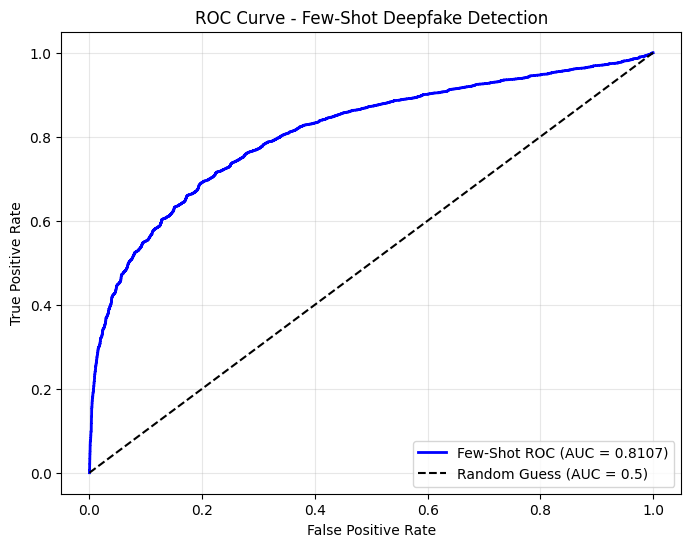

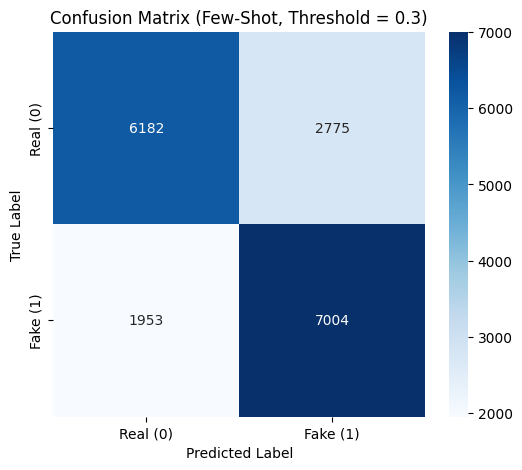

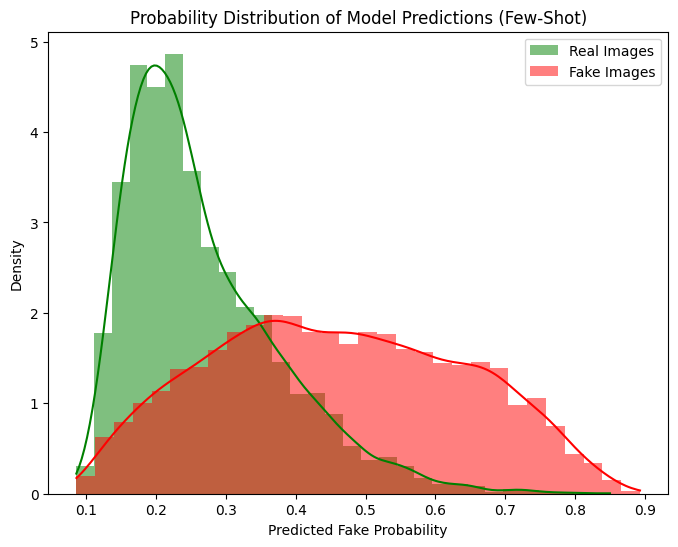

No training loss history found. Skipping Loss graph.
✅ Success! All graphs have been saved to your Drive at: /content/drive/MyDrive/Deepfake_Project/Graphs_FewShot


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
import os

# 1. Create a folder in your Drive to save the graphs safely (UPDATED TO FEW-SHOT)
graph_dir = "/content/drive/MyDrive/Deepfake_Project/Graphs_FewShot"
os.makedirs(graph_dir, exist_ok=True)

print("Generating and saving graphs...")

# 2. ROC Curve (UPDATED TITLE)
fpr, tpr, _ = roc_curve(all_true_numerical_labels, all_fake_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Few-Shot ROC (AUC = {auc_score:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Few-Shot Deepfake Detection')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_fewshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
optimal_thresh = best_thresh
binary_preds = [1 if prob >= optimal_thresh else 0 for prob in all_fake_probabilities]
cm = confusion_matrix(all_true_numerical_labels, binary_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Few-Shot, Threshold = {optimal_thresh})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_fewshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Probability Distribution Plot
plt.figure(figsize=(8, 6))
real_probs = [prob for prob, label in zip(all_fake_probabilities, all_true_numerical_labels) if label == 0]
fake_probs = [prob for prob, label in zip(all_fake_probabilities, all_true_numerical_labels) if label == 1]

sns.histplot(real_probs, color='green', label='Real Images', kde=True, stat="density", linewidth=0, alpha=0.5, bins=30)
sns.histplot(fake_probs, color='red', label='Fake Images', kde=True, stat="density", linewidth=0, alpha=0.5, bins=30)

plt.xlabel('Predicted Fake Probability')
plt.ylabel('Density')
plt.title('Probability Distribution of Model Predictions (Few-Shot)')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_fewshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 5. NEW: Training Loss Convergence Graph
# This will only plot if the list exists (which it does, from Cell 5)
if 'training_loss_history' in locals() and len(training_loss_history) > 0:
    plt.figure(figsize=(8, 6))
    plt.plot(training_loss_history, label='Training Loss', color='purple', linewidth=2)
    plt.xlabel('Batch / Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss Convergence (Few-Shot)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(graph_dir, 'training_loss_fewshot.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No training loss history found. Skipping Loss graph.")

print(f"✅ Success! All graphs have been saved to your Drive at: {graph_dir}")